In [80]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_3level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_3level, get_predict
from tradepy.paths import MODELS_DIR

from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, f1_score, accuracy_score, mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, mean_absolute_percentage_error, log_loss

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

import seaborn as sns

import pandas as pd

import numpy as np

import json

import torch.nn as nn
import torch

In [3]:
symbols = load_symbols()
cfg = load_config()
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880
ASSET = symbols[5]

In [4]:
print(f"Procesando {ASSET}...")
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")
exclude = load_exclude_config(MINUTES)
df_final_triple_real = target_triple_barrier_interday(df_final, spec, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]
df_final_triple_real["target_regression"] = df_final_triple_real[f"log_return_horizon_{RETURN_HORIZON_MIN}m"]
feature_cols_triple = [c for c in df_final_triple_real.columns if c not in exclude['exclude_cols_triple']]
df_final_triple_real = df_final_triple_real.dropna(subset=["target_class", "target_regression"])
features_finales_test, params = filter_features(df_final_triple_real, feature_cols_triple, 'target_class', horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES)
result_3, result_by_fold_3, df_losses, model_l1, model_l2, model_l3, sc, sc_l3 = train_walk_forward_3level(df_final_triple_real, features_finales_test, 'target_class', 'target_regression', BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicLSTM_L3_Regression, 
                        train_size=params["train_size"],
                        test_size=params["test_size"],
                        gap=params["gap"],
                        lookback=params["lookback"],
                        epochs=15,
                        batch_size=256,
                        lr=5e-4)
best_params, df_grid = grid_search_thresholds(result_3)
res = get_predict(result_3, best_params)
evaluate_model_classification(res, False, True, f"{MODELS_DIR}/{ASSET.lower()}/classification_report.png")

Procesando GC...
Eliminando 54 features redundantes por correlación
Configuración sugerida:
{'lookback': 30, 'train_size': 6000, 'test_size': 180, 'gap': 12, '_candles_per_day': 6, '_horizon_bars': 12}
Features seleccionadas (61):
['volume_cum' 'macd' 'signal' 'histogram' 'adx' 'rsi' 'slowk' 'cmo'
 'williams_r' 'cci' 'roc_10' 'roc_5' 'hv' 'obv' 'obv_norm' 'obv_roc_5'
 'obv_roc_10' 'obv_z' 'obv_rel' 'ad_roc_5' 'ad_roc_10' 'ad_z' 'ad_rel'
 'volume_range' 'volume_price' 'mfi' 'cmf' 'efi' 'avg_volume'
 'relative_volume' 'volume_delta' 'pct_above_ma_20' 'pct_above_ma_50'
 'slope_10' 'dist_low_cum_ticks' 'dist_open_day_ticks'
 'vol_weight_intraday' 'hour' 'hour_sin' 'is_ny' 'return_lag_1'
 'return_lag_5' 'return_lag_10' 'return_lag_20' 'return_std_5'
 'return_std_10' 'bb_width' 'rolling_skew_10' 'rolling_kurt_10'
 'rolling_skew_20' 'rolling_kurt_20' 'dist_to_last_swing_high'
 'dist_to_last_swing_low' 'swing_range' 'swing_range_pct'
 'close_in_swing_range' 'atr_norm' 'atr_z' 'dist_to_nearest_

WF 3-Level:   0%|          | 0/134 [00:00<?, ?it/s]E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:542: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:588: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-ra

Métrica: f1_macro
Mejor score: 0.4754 con {'threshold_move': 0.65, 'threshold_dir': 0.5}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.65           0.50    0.4754
           0.65            NaN    0.4754
           0.70            NaN    0.4746
           0.70           0.50    0.4746
           0.65           0.55    0.4710
           0.60            NaN    0.4693
           0.60           0.50    0.4693
           0.70           0.55    0.4685
           0.60           0.55    0.4670
           0.65           0.60    0.4638
📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.37      0.41      0.39      4809
    HOLD (1)       0.71      0.65      0.68     14776
     BUY (2)       0.34      0.38      0.36      4535

    accuracy                           0.55     24120
   macro avg       0.47      0.48      0.48     24120
weighted avg       0.57      0.55      0.56     24120

💾 Figura guardada en: E:\Futuro\MLAl

{'accuracy': 0.5532338308457712, 'f1_macro': 0.47535946342403923}

In [33]:
def evaluate_model_classification(full_results, show=True, save=False, save_path="classification_report.png"):

    df = full_results.copy()
    
    # Aseguramos que los tipos sean correctos
    y_true = df['actual'].astype(int)
    y_pred = df['final_pred'].astype(int)

    # 1. Reporte detallado
    print("📊 --- CLASIFICACIÓN POR CLASE ---")
    print(classification_report(
        y_true, y_pred,
        target_names=['SELL (0)', 'HOLD (1)', 'BUY (2)'],
        zero_division=0
    ))

    # 2. Matrices de confusión
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    # 3. F1 por clase
    f1_classes = f1_score(y_true, y_pred, average=None)
    f1_matrix = f1_classes.reshape(1, -1)

    # 4. Métricas por clase (para barplot)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    metrics_df = pd.DataFrame(report).T.loc[['0','1','2'], ['precision','recall','f1-score']]
    metrics_df.index = ['SELL','HOLD','BUY']

    # --- FIGURA 2x2 ---
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    # --- Plot 1: Confusion Matrix (conteos)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0,0],
                xticklabels=['SELL','HOLD','BUY'], yticklabels=['SELL','HOLD','BUY'])
    ax[0,0].set_title("Confusion Matrix (Conteos)")

    # --- Plot 2: Confusion Matrix Normalizada
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=ax[0,1],
                xticklabels=['SELL','HOLD','BUY'], yticklabels=['SELL','HOLD','BUY'])
    ax[0,1].set_title("Confusion Matrix (Recall por Clase)")

    # --- Plot 3: F1 por clase
    sns.heatmap(f1_matrix, annot=True, fmt='.3f', cmap='Purples', ax=ax[1,0],
                xticklabels=['SELL','HOLD','BUY'], yticklabels=['F1-score'])
    ax[1,0].set_title("F1-score por Clase")

    # --- Plot 4: Precision / Recall / F1 por clase
    metrics_df.plot(kind='bar', ax=ax[1,1], colormap='viridis')
    ax[1,1].set_ylim(0, 1)
    ax[1,1].set_title("Métricas por Clase")
    ax[1,1].legend(loc='lower right')

    plt.tight_layout()

    # Guardar si save=True
    if save:
        fig.savefig(save_path, dpi=300)
        print(f"💾 Figura guardada en: {save_path}")

    # Mostrar si show=True
    if show:
        plt.show()
    else:
        plt.close(fig)

    # 5. Métricas globales
    f1_macro = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)

    print(f"\n⭐ Métricas Globales:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (Macro): {f1_macro:.4f}  <-- Si es < 0.33, el modelo es puro azar")

    # return {"accuracy": acc, "f1_macro": f1_macro}
    return {
        "classification": {
            "accuracy": float(acc),
            "f1_macro": float(f1_macro),
            "f1_per_class": {
                "SELL": float(f1_classes[0]),
                "HOLD": float(f1_classes[1]),
                "BUY": float(f1_classes[2])
            },
            "confusion_matrix": cm.tolist(),
            "confusion_matrix_normalized": cm_norm.tolist(),
            "per_class_metrics": metrics_df.to_dict()
        }
    }



In [34]:
emc = evaluate_model_classification(res, False, True, f"{MODELS_DIR}/{ASSET.lower()}/classification_report_LSTM.png")

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.37      0.41      0.39      4809
    HOLD (1)       0.71      0.65      0.68     14776
     BUY (2)       0.34      0.38      0.36      4535

    accuracy                           0.55     24120
   macro avg       0.47      0.48      0.48     24120
weighted avg       0.57      0.55      0.56     24120

💾 Figura guardada en: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/classification_report_LSTM.png

⭐ Métricas Globales:
Accuracy: 0.5532
F1-Score (Macro): 0.4754  <-- Si es < 0.33, el modelo es puro azar


In [21]:
res_wo_nan = res.dropna(subset=["prob_move", "prob_hold", "actual"]).copy()
y_true_L1 = (res_wo_nan['actual'] != 1).astype(int)
# y_score: probabilidad de la clase positiva (MOVE)
y_score_L1 = res_wo_nan['prob_move']
fpr_L1, tpr_L1, thr_L1 = roc_curve(y_true_L1, y_score_L1)
auc_L1 = auc(fpr_L1, tpr_L1)

df_L2 = res_wo_nan[res_wo_nan['actual'] != 1].copy()   # solo BUY o SELL
# y_true: 1 = BUY, 0 = SELL
y_true_L2 = (df_L2['actual'] == 2).astype(int)
# y_score: probabilidad de BUY
y_score_L2 = df_L2['prob_buy']
fpr_L2, tpr_L2, thr_L2 = roc_curve(y_true_L2, y_score_L2)
auc_L2 = auc(fpr_L2, tpr_L2)
df_L1 = res_wo_nan.copy()
y_true_L1 = (df_L1['actual'] != 1).astype(int)
y_prob_L1 = df_L1['prob_move']
prob_true_L1, prob_pred_L1 = calibration_curve(
    y_true_L1, y_prob_L1, n_bins=10, strategy='uniform'
)

# L2: BUY vs SELL (solo cuando actual != 1)
df_L2 = res_wo_nan[res_wo_nan['actual'] != 1].copy()
y_true_L2 = (df_L2['actual'] == 2).astype(int)
y_prob_L2 = df_L2['prob_buy']
prob_true_L2, prob_pred_L2 = calibration_curve(
    y_true_L2, y_prob_L2, n_bins=10, strategy='uniform'
)

In [35]:
def plot_roc_and_reliability_2x2(
    fpr_L1, tpr_L1, auc_L1,
    fpr_L2, tpr_L2, auc_L2,
    prob_pred_L1, prob_true_L1,
    prob_pred_L2, prob_true_L2,
    show=True, save=False, save_path="roc_reliability_2x2.png"
):

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    # --- ROC L1 ---
    ax[0,0].plot(fpr_L1, tpr_L1, label=f"AUC L1 = {auc_L1:.3f}")
    ax[0,0].plot([0,1],[0,1],'--',color='gray')
    ax[0,0].set_title("ROC L1: MOVE vs HOLD")
    ax[0,0].set_xlabel("False Positive Rate")
    ax[0,0].set_ylabel("True Positive Rate")
    ax[0,0].legend()

    # --- ROC L2 ---
    ax[0,1].plot(fpr_L2, tpr_L2, label=f"AUC L2 = {auc_L2:.3f}")
    ax[0,1].plot([0,1],[0,1],'--',color='gray')
    ax[0,1].set_title("ROC L2: BUY vs SELL")
    ax[0,1].set_xlabel("False Positive Rate")
    ax[0,1].set_ylabel("True Positive Rate")
    ax[0,1].legend()

    # --- Reliability L1 ---
    ax[1,0].plot(prob_pred_L1, prob_true_L1, marker='o', label='L1 calibration')
    ax[1,0].plot([0,1],[0,1],'--',color='gray')
    ax[1,0].set_title("Reliability Curve — L1 MOVE vs HOLD")
    ax[1,0].set_xlabel("Predicted probability (MOVE)")
    ax[1,0].set_ylabel("Observed frequency")
    ax[1,0].grid(True)
    ax[1,0].legend()

    # --- Reliability L2 ---
    ax[1,1].plot(prob_pred_L2, prob_true_L2, marker='o', label='L2 calibration')
    ax[1,1].plot([0,1],[0,1],'--',color='gray')
    ax[1,1].set_title("Reliability Curve — L2 BUY vs SELL")
    ax[1,1].set_xlabel("Predicted probability (BUY)")
    ax[1,1].set_ylabel("Observed frequency")
    ax[1,1].grid(True)
    ax[1,1].legend()

    plt.tight_layout()

    # Guardar si save=True
    if save:
        fig.savefig(save_path, dpi=300)
        print(f"💾 Figura guardada en: {save_path}")

    # Mostrar si show=True
    if show:
        plt.show()
    else:
        plt.close(fig)
        
    return {
    "roc_reliability": {
        "L1": {
            "auc": float(auc_L1),
            "fpr": list(map(float, fpr_L1)),
            "tpr": list(map(float, tpr_L1)),
            "prob_pred": list(map(float, prob_pred_L1)),
            "prob_true": list(map(float, prob_true_L1))
        },
        "L2": {
            "auc": float(auc_L2),
            "fpr": list(map(float, fpr_L2)),
            "tpr": list(map(float, tpr_L2)),
            "prob_pred": list(map(float, prob_pred_L2)),
            "prob_true": list(map(float, prob_true_L2))
        }
    }
}



In [36]:
rr = plot_roc_and_reliability_2x2(fpr_L1, tpr_L1, auc_L1, fpr_L2, tpr_L2, auc_L2, prob_pred_L1, prob_true_L1, prob_pred_L2, prob_true_L2, False, True, f"{MODELS_DIR}/{ASSET.lower()}/auc_roc_reliability_LSTM.png")

💾 Figura guardada en: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/auc_roc_reliability_LSTM.png


In [37]:
def plot_regression_2x2(
    results,
    show=True, save=False, save_path="regression_L3_2x2.png"
):
    df = results.copy()
    df = df.dropna(subset=["pred_logret", "real_logret"])

    y_true = df["real_logret"].astype(float).values
    y_pred = df["pred_logret"].astype(float).values

    # -----------------------------
    # 1. Métricas numéricas
    # -----------------------------
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    medae = median_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    errors = y_pred - y_true
    fitted = y_pred

    # Texto común para la leyenda
    legend_text = (
        f"MAE={mae:.4f}\n"
        f"RMSE={rmse:.4f}\n"
        f"R²={r2:.3f}\n"
        f"Corr={corr:.3f}\n"
        f"MedAE={medae:.4f}\n"
        f"MAPE={mape:.2f}%"
    )

    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    # -----------------------------
    # 1. Scatter Pred vs Real
    # -----------------------------
    sns.scatterplot(x=y_true, y=y_pred, s=10, alpha=0.4, ax=ax[0,0])
    ax[0,0].set_title("Scatter Pred vs Real")
    ax[0,0].set_xlabel("Real log-return")
    ax[0,0].set_ylabel("Predicted log-return")
    ax[0,0].axhline(0, color='gray', linestyle='--')
    ax[0,0].axvline(0, color='gray', linestyle='--')
    ax[0,0].grid(alpha=0.3)

    # -----------------------------
    # 2. Histograma del error
    # -----------------------------
    sns.histplot(errors, bins=50, kde=True, ax=ax[0,1])
    ax[0,1].set_title("Distribución del Error (pred - real)")
    ax[0,1].set_xlabel("Error")
    ax[0,1].grid(alpha=0.3)

    # -----------------------------
    # 3. KDE conjunta
    # -----------------------------
    sns.kdeplot(x=y_true, y=y_pred, fill=True, cmap="viridis", thresh=0.05, ax=ax[1,0])
    ax[1,0].set_title("Densidad conjunta Pred vs Real")
    ax[1,0].set_xlabel("Real log-return")
    ax[1,0].set_ylabel("Predicted log-return")
    ax[1,0].grid(alpha=0.3)

    # -----------------------------
    # 4. Residuals vs Fitted
    # -----------------------------
    sns.scatterplot(x=fitted, y=errors, s=10, alpha=0.4, ax=ax[1,1])
    ax[1,1].axhline(0, color='gray', linestyle='--')
    ax[1,1].set_title("Residuals vs Fitted")
    ax[1,1].set_xlabel("Predicted log-return")
    ax[1,1].set_ylabel("Residuals")
    ax[1,1].grid(alpha=0.3)

    # -----------------------------
    # Leyenda común
    # -----------------------------
    # fig.text(0.92, 0.5, legend_text, fontsize=12, va='center')

    plt.tight_layout(rect=[0, 0, 0.9, 1])

    # Guardar
    if save:
        fig.savefig(save_path, dpi=300)
        print(f"💾 Figura guardada en: {save_path}")

    # Mostrar
    if show:
        plt.show()
    else:
        plt.close(fig)
        
    return {
        "regression": {
            "mae": float(mae),
            "rmse": float(rmse),
            "r2": float(r2),
            "corr": float(corr),
            "medae": float(medae),
            "mape": float(mape),
            "errors": errors.tolist(),
            "fitted": fitted.tolist()
        }
    }



In [38]:
reg = plot_regression_2x2(res, False, True, f"{MODELS_DIR}/{ASSET.lower()}/regression_LSTM.png")

💾 Figura guardada en: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/regression_LSTM.png


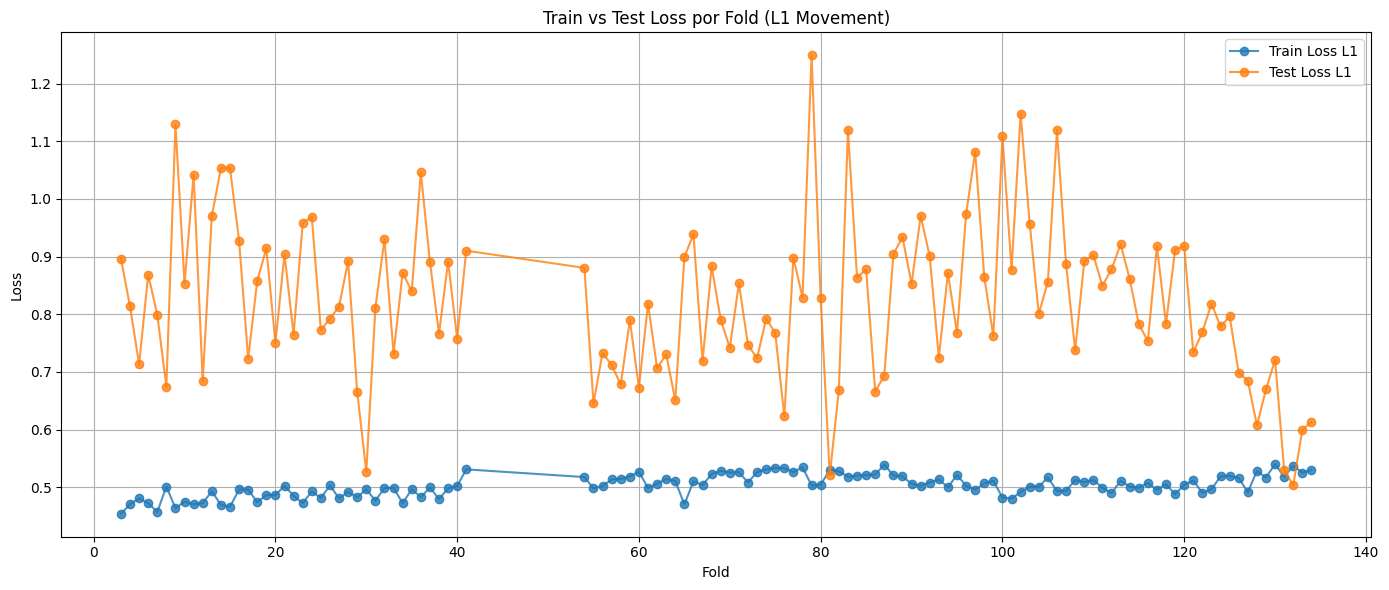

In [53]:
lista_no_na = res.dropna(subset=["prob_move", "prob_hold"]).fold.unique()
df = res.copy()

# Filtrar solo filas con predicción válida
df = df.dropna(subset=["prob_move", "prob_hold"])

test_size = 180

# Número de folds
n_folds = len(df) // test_size

losses_L1 = []

for i in range(n_folds):
    start = i * test_size
    end = start + test_size
    fold_df = df.iloc[start:end]

    # Etiqueta real: 0 = HOLD, 1 = MOVE
    y_true = (fold_df["actual"] != 0).astype(int)

    # Probabilidad de clase positiva (MOVE)
    y_prob = fold_df["prob_move"]

    # Log-loss del fold
    fold_loss = log_loss(y_true, y_prob)
    losses_L1.append(fold_loss)
df_prueba = df_losses.groupby('fold')['loss_l1_move'].last().reset_index()
df_prueba = df_prueba[df_prueba.fold.isin(lista_no_na)]
df_prueba['loss_l1_move_test'] = losses_L1
plt.figure(figsize=(14,6))

plt.plot(df_prueba["fold"], df_prueba["loss_l1_move"], 
         label="Train Loss L1", marker="o", alpha=0.8)

plt.plot(df_prueba["fold"], df_prueba["loss_l1_move_test"], 
         label="Test Loss L1", marker="o", alpha=0.8)

plt.xlabel("Fold")
plt.ylabel("Loss")
plt.title("Train vs Test Loss por Fold (L1 Movement)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
res.head()

,fold,datetime,actual,prob_hold,prob_move,prob_sell,prob_buy,pred_logret,real_logret,pred_move,pred_dir,final_pred
0,1,2010-10-18 16:00:00,0.0,NaN,NaN,NaN,NaN,NaN,-0.016704,0,1,1
1,1,2010-10-18 20:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.011259,0,1,1
2,1,2010-10-19 00:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008217,0,1,1
3,1,2010-10-19 04:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.003267,0,1,1
4,1,2010-10-19 08:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008436,0,1,1


In [57]:
df_losses.head()

,fold,epoch,loss_l1_move,loss_l2_dir,loss_l3_reg
0,1,1,0.747005,NaN,NaN
1,1,2,0.744519,NaN,NaN
2,1,3,0.740244,NaN,NaN
3,1,4,0.736283,NaN,NaN
4,1,5,0.735035,NaN,NaN


In [81]:
def compute_test_losses(res, df_losses, sc_l3, test_size=180):
    """
    Calcula test losses fold-by-fold para L1, L2 y L3 (HuberLoss),
    usando el MISMO scaler que en entrenamiento.
    """

    df = res.copy()
    df = df.dropna(subset=["prob_move", "prob_hold"], how="any")

    lista_no_na = df.fold.unique()
    n_folds = len(df) // test_size

    losses_L1 = []
    losses_L2 = []
    losses_L3 = []

    huber = nn.HuberLoss(delta=1.0)

    for i in range(n_folds):
        start = i * test_size
        end = start + test_size
        fold_df = df.iloc[start:end]

        # -------------------------
        # L1: MOVE vs HOLD
        # -------------------------
        y_true_L1 = (fold_df["actual"] != 0).astype(int)
        y_prob_L1 = fold_df["prob_move"]
        loss_L1 = log_loss(y_true_L1, y_prob_L1)
        losses_L1.append(loss_L1)

        # -------------------------
        # L2: BUY vs SELL
        # -------------------------
        if "prob_buy" in fold_df.columns:
            df_L2 = fold_df[fold_df["actual"] != 0]
            if len(df_L2) > 0:
                y_true_L2 = (df_L2["actual"] == 2).astype(int)
                y_prob_L2 = df_L2["prob_buy"]
                loss_L2 = log_loss(y_true_L2, y_prob_L2)
            else:
                loss_L2 = np.nan
            losses_L2.append(loss_L2)

        # -------------------------
        # L3: REGRESIÓN (HuberLoss con scaler)
        # -------------------------
        if "pred_logret" in fold_df.columns:

            df_L3 = fold_df.dropna(subset=["pred_logret", "real_logret"])

            if len(df_L3) > 0:
                real_scaled = sc_l3.transform(df_L3["real_logret"].values.reshape(-1,1)).flatten()
                pred_scaled = sc_l3.transform(df_L3["pred_logret"].values.reshape(-1,1)).flatten()

                real_t = torch.tensor(real_scaled, dtype=torch.float32)
                pred_t = torch.tensor(pred_scaled, dtype=torch.float32)

                loss_L3 = huber(pred_t, real_t).item()
            else:
                loss_L3 = np.nan

            losses_L3.append(loss_L3)

    # -------------------------
    # Construir df final
    # -------------------------
    df_test = df_losses.groupby("fold").last().reset_index()
    df_test = df_test[df_test.fold.isin(lista_no_na)]

    df_test["loss_l1_move_test"] = losses_L1

    if len(losses_L2) > 0:
        df_test["loss_l2_dir_test"] = losses_L2

    if len(losses_L3) > 0:
        df_test["loss_l3_reg_test"] = losses_L3

    return df_test


In [99]:
def plot_losses_by_fold(
    df_losses,
    df_test_losses=None,
    show=True,
    save=False,
    save_path="losses_by_fold.png"
):
    """
    Dibuja automáticamente los losses disponibles:
    - L1 clasificación (move)
    - L2 clasificación (dir)
    - L3 regresión (reg)
    Y añade un cuarto panel con la diferencia test - train por fold.
    """

    # Detectar qué losses existen
    available_losses = []
    if "loss_l1_move" in df_losses.columns:
        available_losses.append(("L1 Movement", "loss_l1_move", "loss_l1_move_test"))
    if "loss_l2_dir" in df_losses.columns:
        available_losses.append(("L2 Direction", "loss_l2_dir", "loss_l2_dir_test"))
    if "loss_l3_reg" in df_losses.columns:
        available_losses.append(("L3 Regression", "loss_l3_reg", "loss_l3_reg_test"))

    n = len(available_losses)

    # Layout: siempre 2x2 si hay más de 2 losses
    if n <= 2:
        fig, ax = plt.subplots(1, n, figsize=(14, 5))
        if n == 1:
            ax = [ax]
    else:
        fig, ax = plt.subplots(2, 2, figsize=(14, 10))
        ax = ax.flatten()

    # Dibujar cada loss
    for i, (title, train_col, test_col) in enumerate(available_losses):

        df_train = df_losses.groupby("fold")[train_col].last().reset_index()

        if df_test_losses is not None and test_col in df_test_losses.columns:
            df_test = df_test_losses[["fold", test_col]]
        else:
            df_test = None

        ax[i].plot(df_train["fold"], df_train[train_col],
                   label=f"Train {title}", marker="o", alpha=0.8)

        if df_test is not None:
            ax[i].plot(df_test["fold"], df_test[test_col],
                       label=f"Test {title}", marker="o", alpha=0.8)

        ax[i].set_title(f"{title} Loss por Fold")
        ax[i].set_xlabel("Fold")
        ax[i].set_ylabel("Loss")
        ax[i].grid(True)
        ax[i].legend()

    # -----------------------------------------
    # PANEL EXTRA: diferencias test - train
    # -----------------------------------------
    if n >= 2:  # solo si hay más de un loss
        idx = 3 if n == 3 else n  # último panel disponible

        ax_extra = ax[idx] if n > 2 else None
        if ax_extra is None:
            fig_extra, ax_extra = plt.subplots(1, 1, figsize=(7, 5))

        for title, train_col, test_col in available_losses:
            if df_test_losses is not None and test_col in df_test_losses.columns:
                df_train = df_losses.groupby("fold")[train_col].last().reset_index()
                df_test = df_test_losses[["fold", test_col]]

                merged = df_train.merge(df_test, on="fold", how="inner")
                merged["diff"] = merged[test_col] - merged[train_col]

                ax_extra.plot(
                    merged["fold"], merged["diff"],
                    marker="o", alpha=0.8, label=f"{title} (Test - Train)"
                )

        ax_extra.axhline(0, color="gray", linestyle="--", alpha=0.6)
        ax_extra.set_title("Diferencia Test - Train por Fold")
        ax_extra.set_xlabel("Fold")
        ax_extra.set_ylabel("Test - Train")
        ax_extra.grid(True)
        ax_extra.legend()

    plt.tight_layout()

    if save:
        fig.savefig(save_path, dpi=300)
        print(f"💾 Figura guardada en: {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)
    


In [100]:
plot_losses_by_fold(df_losses, compute_test_losses(res, df_losses, sc_l3), False, True, f"{MODELS_DIR}/{ASSET.lower()}/loss_LSTM.png")

💾 Figura guardada en: E:\Futuro\MLAlgoTrading\TradingBots\Models/gc/loss_LSTM.png


In [88]:
def build_loss_report(df_losses, df_test):
    report = {}

    for name, train_col, test_col in [
        ("L1", "loss_l1_move", "loss_l1_move_test"),
        ("L2", "loss_l2_dir", "loss_l2_dir_test"),
        ("L3", "loss_l3_reg", "loss_l3_reg_test")
    ]:
        if train_col not in df_losses.columns:
            continue

        # Train por fold
        train = df_losses.groupby("fold")[train_col].last().reset_index()

        # Test por fold
        if test_col in df_test.columns:
            test = df_test[["fold", test_col]]
            merged = train.merge(test, on="fold", how="inner")
            gap = merged[test_col] - merged[train_col]
        else:
            merged = train.copy()
            merged[test_col] = None
            gap = None

        report[name] = {
            "train": merged[train_col].tolist(),
            "test": merged[test_col].tolist(),
            "gap": gap.tolist() if gap is not None else None,
            "summary": {
                "train_mean": float(merged[train_col].mean()),
                "train_std": float(merged[train_col].std()),
                "test_mean": float(merged[test_col].mean()) if test_col in df_test.columns else None,
                "test_std": float(merged[test_col].std()) if test_col in df_test.columns else None,
                "gap_mean": float(gap.mean()) if gap is not None else None
            }
        }

    return {"losses": report}


In [ ]:
loss_report = build_loss_report(df_losses, df_prueba)

In [101]:
compute_test_losses(res, df_losses, sc_l3).head()

,fold,epoch,loss_l1_move,loss_l2_dir,loss_l3_reg,loss_l1_move_test,loss_l2_dir_test,loss_l3_reg_test
2,3,15,0.453849,0.457535,0.065846,0.896384,1.125577,0.052359
3,4,15,0.470434,0.451200,0.068441,0.813765,0.928197,0.041360
4,5,15,0.480424,0.455155,0.067243,0.713014,1.156413,0.059086
5,6,15,0.472287,0.440646,0.065285,0.868765,1.339036,0.035808
6,7,15,0.457006,0.430330,0.067156,0.799172,0.866090,0.039658


In [102]:
df_prueba

,fold,loss_l1_move,loss_l1_move_test
2,3,0.453849,0.896384
3,4,0.470434,0.813765
4,5,0.480424,0.713014
5,6,0.472287,0.868765
6,7,0.457006,0.799172
...,...,...,...
129,130,0.540190,0.720781
130,131,0.518041,0.529936
131,132,0.537134,0.503109
132,133,0.525002,0.599714


In [91]:
final_report = {
    **emc,
    **rr,
    **reg,
    **loss_report
}

In [92]:
with open(f"{MODELS_DIR}/{ASSET}/train_metrics.json", "w") as f:
    json.dump(final_report, f, indent=4)

In [94]:
pd.read_json(f"{MODELS_DIR}/{ASSET}/train_metrics.json")

,classification,roc_reliability,regression,losses
accuracy,0.553234,NaN,NaN,NaN
f1_macro,0.475359,NaN,NaN,NaN
f1_per_class,"{'SELL': 0.38921568627450903, 'HOLD': 0.677856...",NaN,NaN,NaN
confusion_matrix,"[[1985, 2010, 814], [2599, 9632, 2545], [807, ...",NaN,NaN,NaN
confusion_matrix_normalized,"[[0.41276772717820703, 0.417966313162819, 0.16...",NaN,NaN,NaN
per_class_metrics,"{'precision': {'SELL': 0.368206269708773, 'HOL...",NaN,NaN,NaN
L1,NaN,"{'auc': 0.670993982918007, 'fpr': [0.0, 0.0, 0...",NaN,"{'train': [0.45384857431054104, 0.470433903237..."
L2,NaN,"{'auc': 0.78901923601512, 'fpr': [0.0, 0.0, 0....",NaN,"{'train': [None, None, 0.45753540264235604, 0...."
mae,NaN,NaN,0.004391,NaN
rmse,NaN,NaN,0.006615,NaN


In [103]:
symbols = load_symbols()


In [105]:
symbols[:2]

['AD', 'BP']